# Аналіз зв'язку різних факторів та рівня захворювання туберкульозом
Завантаження необхідних бібліотек та імпорт даних.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, classification_report, silhouette_score, confusion_matrix
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor,
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import f1_score


filename = "...data/exported_from_db/fact_health_stats.csv" 

df = pd.read_csv(filename, header=0)

# Розраховуємо коефіцієнт інфікованості
df['infected_ratio'] = df['infected_num'] / df['population']

# Розраховуємо співвідношення ВІЛ серед хворих на туберкульоз
df['hiv_in_tb_ratio'] = df['infected_with_hiv_num'] / df['infected_num']

# Обробка можливих пустих значень (NaN) або ділення на 0 (inf)
df['hiv_in_tb_ratio'] = pd.to_numeric(df['hiv_in_tb_ratio'], errors='coerce')
df['hiv_in_tb_ratio'] = df['hiv_in_tb_ratio'].replace([np.inf, -np.inf], np.nan)

df['hiv_in_tb_ratio'] = df.groupby('country_id')['hiv_in_tb_ratio'].transform(lambda x: x.fillna(x.mean()))
df['hiv_in_tb_ratio'] = df['hiv_in_tb_ratio'].fillna(df['hiv_in_tb_ratio'].mean())

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1716 entries, 0 to 1715
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   fact_id                   1716 non-null   int64  
 1   country_id                1716 non-null   int64  
 2   year_id                   1716 non-null   int64  
 3   language_id               1716 non-null   int64  
 4   religion_id               1716 non-null   int64  
 5   region_id                 1716 non-null   int64  
 6   population                1716 non-null   int64  
 7   infected_num              1716 non-null   int64  
 8   infected_with_hiv_num     1716 non-null   int64  
 9   case_detection_rate       1716 non-null   float64
 10  case_fatality_rate        1716 non-null   float64
 11  smoking_prevalence        1716 non-null   float64
 12  gdp_per_capita            1716 non-null   float64
 13  health_development_ratio  1716 non-null   float64
 14  human_development_i

In [7]:
df.describe()

,fact_id,country_id,year_id,language_id,religion_id,region_id,population,infected_num,infected_with_hiv_num,case_detection_rate,case_fatality_rate,smoking_prevalence,gdp_per_capita,health_development_ratio,human_development_index
count,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1.716000e+03,1.716000e+03,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000,1716.000000
mean,858.500000,67.107226,7.020979,20.917249,4.606643,2.991841,4.109542e+07,7.312893e+04,22451.646270,71.526212,0.174103,17.724650,18457.672348,5.902279,0.643388
std,495.510848,38.814144,3.739884,17.152688,0.832813,1.390490,1.547207e+08,3.314672e+05,124261.192285,20.336651,0.134177,8.469175,87507.656576,6.936501,0.289988
min,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,6.568300e+04,0.000000e+00,0.000000,2.600000,0.000000,3.700000,111.930000,0.000000,0.000000
25%,429.750000,33.750000,4.000000,7.000000,4.000000,2.000000,2.626002e+06,5.800000e+02,17.000000,57.000000,0.080000,10.800000,998.752500,0.820000,0.415750
50%,858.500000,67.000000,7.000000,13.000000,5.000000,3.000000,8.854746e+06,4.850000e+03,180.000000,80.000000,0.130000,17.100000,3567.135000,2.950000,0.725000
75%,1287.250000,101.000000,10.000000,32.000000,5.000000,4.000000,2.534673e+07,2.500000e+04,2200.000000,87.000000,0.250000,24.025000,12213.187500,8.237500,0.902250
max,1716.000000,134.000000,13.000000,64.000000,7.000000,6.000000,1.369521e+09,3.590000e+06,999999.000000,170.000000,1.000000,49.400000,999999.000000,33.170000,1.154000


In [10]:
df.head()

,fact_id,country_id,year_id,language_id,religion_id,region_id,population,infected_num,infected_with_hiv_num,case_detection_rate,case_fatality_rate,smoking_prevalence,gdp_per_capita,health_development_ratio,human_development_index,democracy,monarchy,infected_ratio,hiv_in_tb_ratio
0,1,1,1,20,4,1,20130323,38000,6,19.0,0.37,11.8,365.66,0.43,0.120,autocracy,NaN,0.001888,0.000158
1,2,5,1,7,5,3,16194869,48000,9900,33.0,0.30,8.9,556.84,0.23,0.123,autocracy,NaN,0.002964,0.206250
2,3,2,1,50,4,2,3166141,700,1,86.0,0.03,20.0,1126.68,2.72,0.762,democracy,republic,0.000221,0.001429
3,4,4,1,64,5,2,65683,14,999999,87.0,0.08,30.5,21854.25,0.00,0.000,democracy,NaN,0.000213,71428.500000
4,5,6,1,9,5,4,37213982,14000,1000,86.0,0.08,23.7,7708.10,3.75,0.868,democracy,republic,0.000376,0.071429


# Аналіз кореляцій
Визначимо, які параметри найбільше корелюють з рівнем захворюваності на туберкульоз (`infected_ratio`).

The Pearson Correlation Coefficient between 'infected_ratio' and 'population' is 0.0655 with a P-value of 0.006608
The Pearson Correlation Coefficient between 'infected_ratio' and 'case_detection_rate' is -0.5936 with a P-value of 6.237e-164
The Pearson Correlation Coefficient between 'infected_ratio' and 'case_fatality_rate' is 0.4085 with a P-value of 5.098e-70
The Pearson Correlation Coefficient between 'infected_ratio' and 'smoking_prevalence' is -0.1702 with a P-value of 1.284e-12
The Pearson Correlation Coefficient between 'infected_ratio' and 'gdp_per_capita' is 0.0016 with a P-value of 0.948
The Pearson Correlation Coefficient between 'infected_ratio' and 'health_development_ratio' is -0.4537 with a P-value of 7.232e-88
The Pearson Correlation Coefficient between 'infected_ratio' and 'human_development_index' is -0.5343 with a P-value of 2.892e-127
The Pearson Correlation Coefficient between 'infected_ratio' and 'hiv_in_tb_ratio' is -0.0666 with a P-value of 0.005792
The Pearso

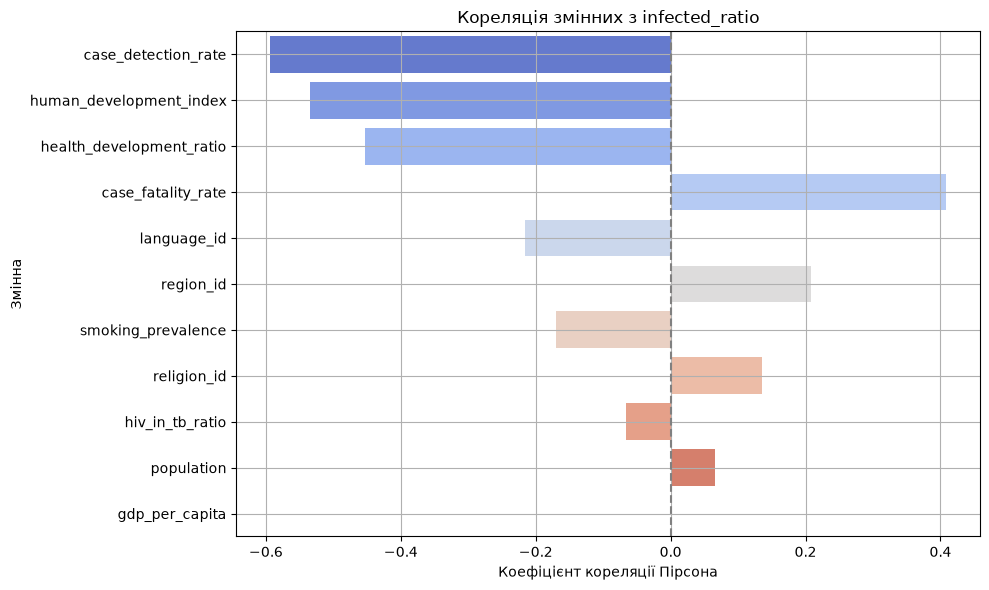

In [11]:
# Список колонок, які перевірятимемо на кореляцію з infected_ratio
target = 'infected_ratio'
features = [
    'population',
    'case_detection_rate',
    'case_fatality_rate',
    'smoking_prevalence',
    'gdp_per_capita',
    'health_development_ratio',
    'human_development_index',
    'hiv_in_tb_ratio',
    'language_id',
    'religion_id',
    'region_id'
]

correlation_results = []

# Обчислення кореляцій
for feature in features:
    pearson_coef, p_value = stats.pearsonr(df[target], df[feature])
    correlation_results.append({
        'feature': feature,
        'pearson_coef': pearson_coef,
        'p_value': p_value
    })
    print(f"The Pearson Correlation Coefficient between '{target}' and '{feature}' is {pearson_coef:.4f} with a P-value of {p_value:.4g}")

corr_df = pd.DataFrame(correlation_results).sort_values(by='pearson_coef', key=abs, ascending=False)

# Побудова графіка
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_df,
    x='pearson_coef',
    y='feature',
    hue='feature',
    palette='coolwarm',
    dodge=False,
    legend=False
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Кореляція змінних з infected_ratio')
plt.xlabel('Коефіцієнт кореляції Пірсона')
plt.ylabel('Змінна')
plt.grid(True)
plt.tight_layout()
plt.show()

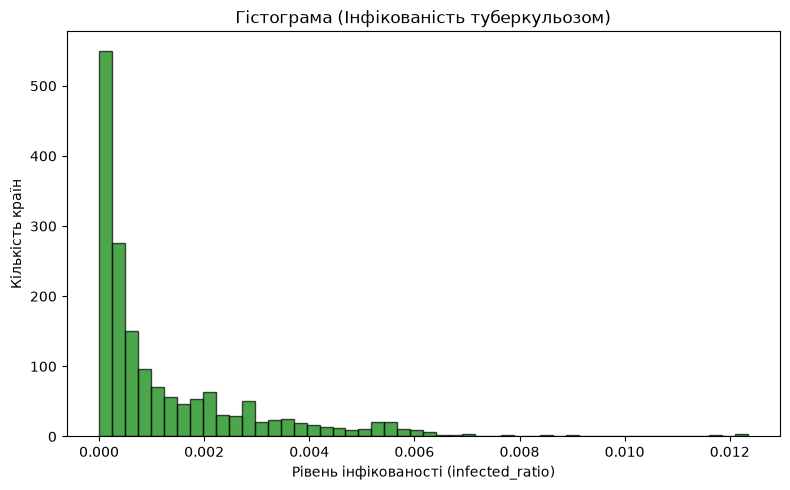

In [12]:
# Гістограма для infected_ratio
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.hist(df["infected_ratio"].dropna(), bins=50, color="green", edgecolor="black", alpha=0.7)
axes.set_title("Гістограма (Інфікованість туберкульозом)", fontsize=12)
axes.set_xlabel("Рівень інфікованості (infected_ratio)")
axes.set_ylabel("Кількість країн")
plt.tight_layout()
plt.show()

# Підготовка даних для класифікації
Розбиваємо рівень захворюваності на 4 категорії та ділимо датасет на навчальну та тестову вибірки.

In [13]:
# Функція для класифікації рівня інфікованості
def classify_infected_level(ratio):
    if ratio < 0.001:
        return 1
    elif 0.001 <= ratio < 0.003:
        return 2
    elif 0.003 <= ratio < 0.005:
        return 3
    else: # 0.005 і більше
        return 4

# Додаємо нову колонку до DataFrame
df['infected_level'] = df['infected_ratio'].apply(classify_infected_level)

# Беремо ті параметри, що найбільше корелюють з infection_rate
all_features = pd.get_dummies(df[['case_detection_rate', 'case_fatality_rate', 'health_development_ratio', 'human_development_index', 'hiv_in_tb_ratio']])
all_features[['infected_level']] = df[['infected_level']]

# Ділимо дані на навчальну та тестову вибірки
df_train, df_test = train_test_split(
    all_features,
    test_size=0.2,
    random_state=1
)

selected_features = ['case_detection_rate', 'case_fatality_rate', 'health_development_ratio', 'human_development_index', 'hiv_in_tb_ratio']

x_train = df_train[selected_features]
y_train = df_train[['infected_level']].values.ravel()

x_test = df_test[selected_features]
y_test = df_test[['infected_level']].values.ravel()

# Модель 1: Gradient Boosting
Підбір параметрів та навчання моделі.

In [14]:
# Підбираємо параметри для GradientBooster
gb = GradientBoostingClassifier(random_state=1)
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(x_train, y_train)

# Виведення результатів
print("Best parameters found:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.8782694094226942


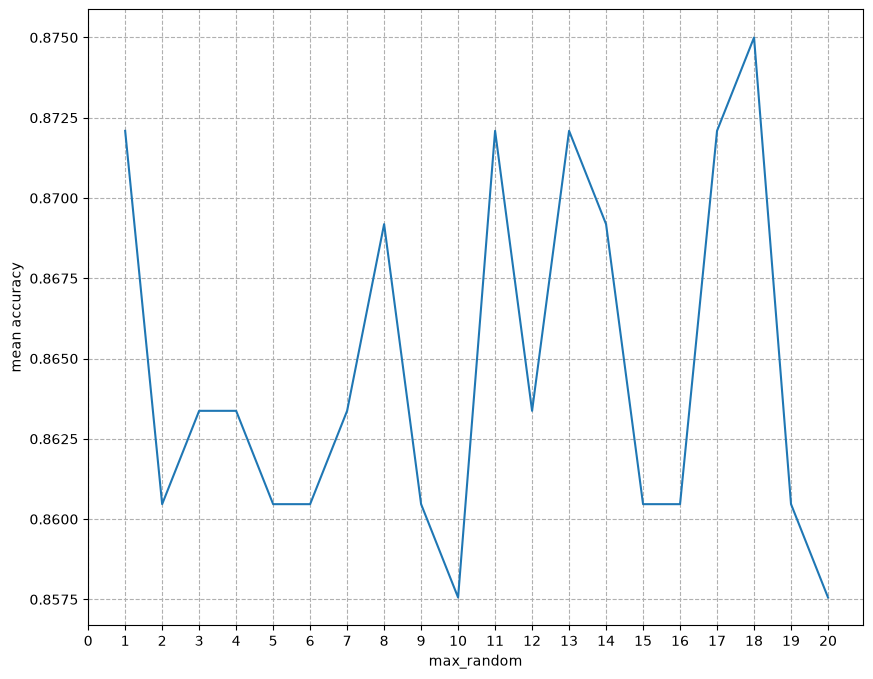

In [15]:
# Підбираємо параметр random_state та будуємо графік точності
accur = []
max_random = 20
for k in range(1, max_random + 1):
    gradboost = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=k)
    gradboost.fit(x_train, y_train)
    accur.append(gradboost.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_random + 1), accur)
plt.xticks(range(0, max_random + 1, 1))
plt.xlabel('max_random')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

In [16]:
# Підставляємо визначені параметри та оцінюємо точність моделі
gradboost = GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, random_state=1)
gradboost.fit(x_train, y_train)
print('Gradient Boosting mean accuracy = ', gradboost.score(x_test, y_test))

Gradient Boosting mean accuracy =  0.872093023255814


# Модель 2: Random Forest
Підбір параметрів та навчання моделі.

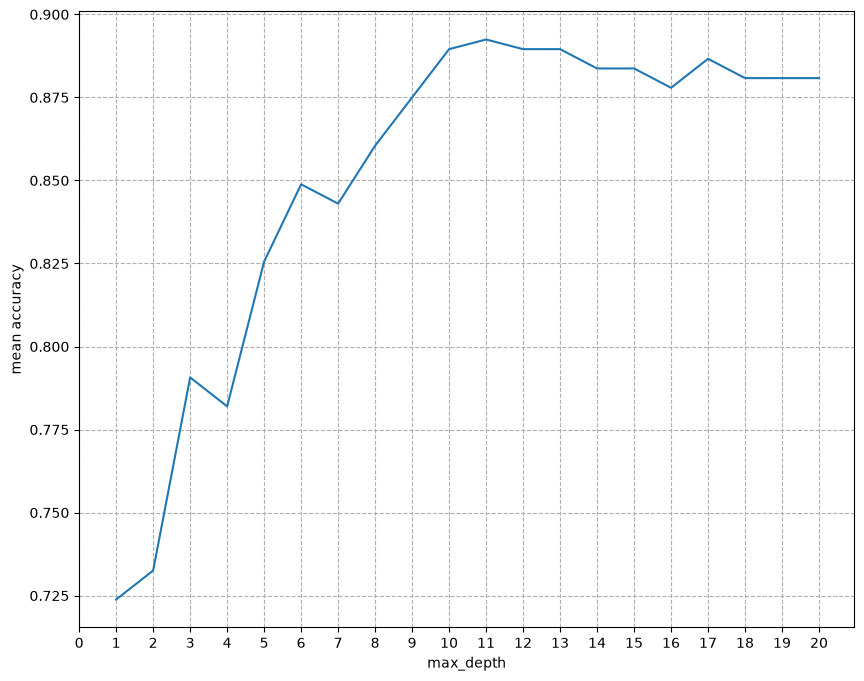

In [17]:
# Підбираємо параметр max_depth та будуємо графік точності
accur = []
max_kernels = 20
for k in range(1, max_kernels + 1):
    randomforest = RandomForestClassifier(max_depth=k, random_state=1)
    randomforest.fit(x_train, y_train)
    accur.append(randomforest.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_kernels + 1), accur)
plt.xticks(range(0, max_kernels + 1, 1))
plt.xlabel('max_depth')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

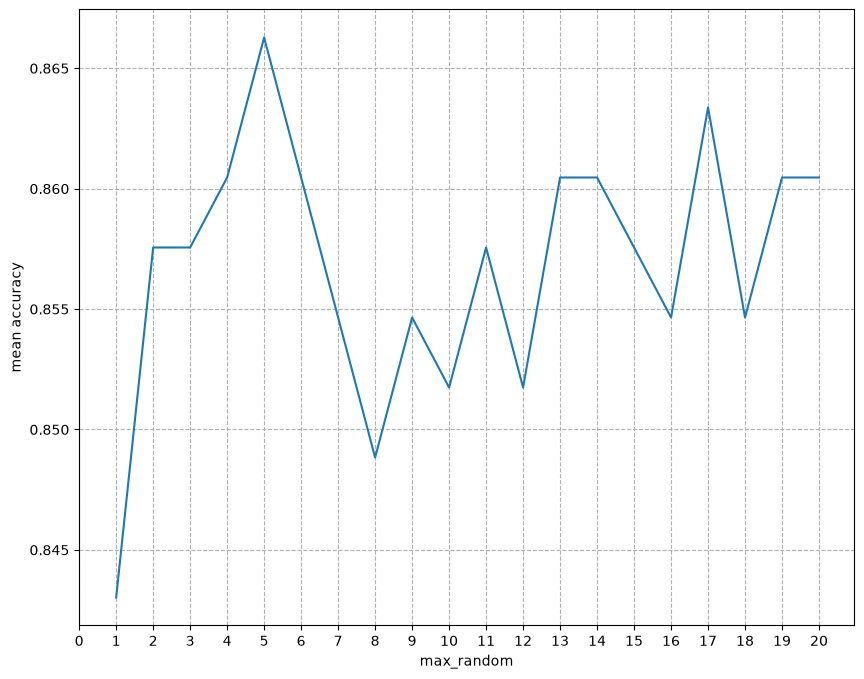

In [18]:
# Підбираємо параметр random_state та будуємо графік точності
accur = []
max_random = 20
for k in range(1, max_random + 1):
    randomforest = RandomForestClassifier(max_depth=7, random_state=k)
    randomforest.fit(x_train, y_train)
    accur.append(randomforest.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_random + 1), accur)
plt.xticks(range(0, max_random + 1, 1))
plt.xlabel('max_random')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

In [20]:
# Підставляємо визначені параметри та оцінюємо точність моделі
randomforest = RandomForestClassifier(max_depth=7, random_state=1)
random_scores = cross_val_score(randomforest, x_train, y_train, cv=5)
print("Cross val mean:", random_scores.mean())
randomforest.fit(x_train, y_train)
print('Random Forest mean accuracy = ', randomforest.score(x_test, y_test))

Cross val mean: 0.8403503649635036
Random Forest mean accuracy =  0.8430232558139535


# Модель 3: Extra Trees
Підбір параметрів та навчання моделі.

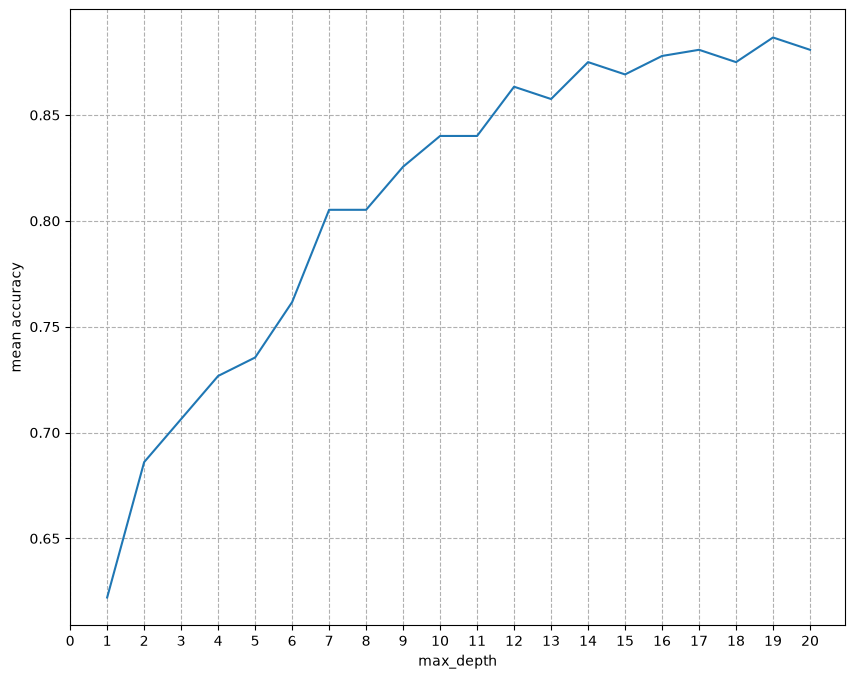

In [21]:
# Підбираємо параметр max_depth та будуємо графік точності
accur = []
max_kernels = 20
for k in range(1, max_kernels + 1):
    extratrees = ExtraTreesClassifier(max_depth=k, random_state=1)
    extratrees.fit(x_train, y_train)
    accur.append(extratrees.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_kernels + 1), accur)
plt.xticks(range(0, max_kernels + 1, 1))
plt.xlabel('max_depth')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

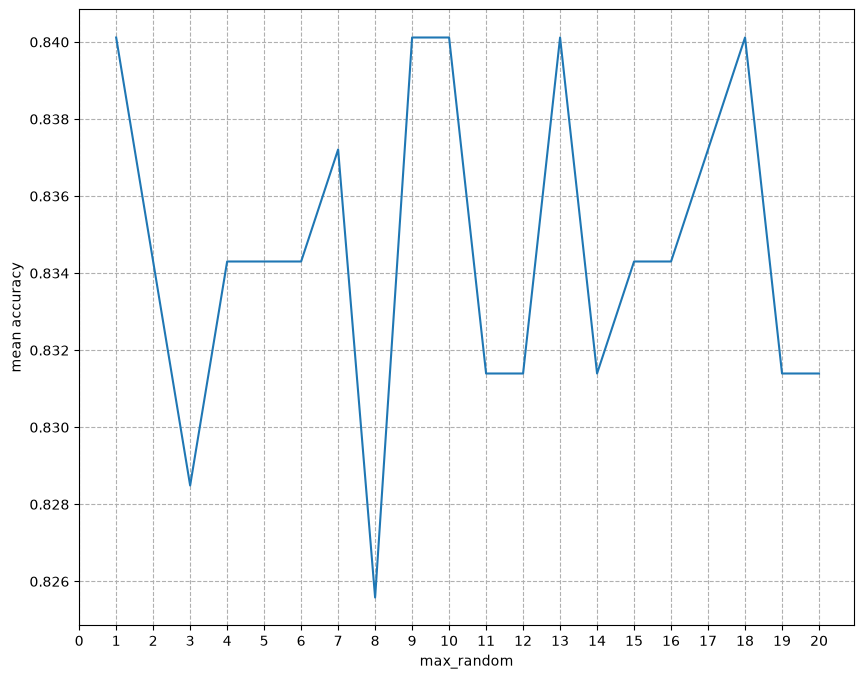

In [22]:
# Підбираємо параметр random_state та будуємо графік точності
accur = []
max_random = 20
for k in range(1, max_random + 1):
    extratrees = ExtraTreesClassifier(max_depth=10, random_state=k)
    extratrees.fit(x_train, y_train)
    accur.append(extratrees.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_random + 1), accur)
plt.xticks(range(0, max_random + 1, 1))
plt.xlabel('max_random')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

In [23]:
# Підставляємо визначені параметри та оцінюємо точність моделі
extratrees = ExtraTreesClassifier(max_depth=10, random_state=10)
extra_scores = cross_val_score(extratrees, x_train, y_train, cv=5)
print("Cross val mean:", extra_scores.mean())
extratrees.fit(x_train, y_train)
print('Extra Trees mean accuracy = ', extratrees.score(x_test, y_test))

Cross val mean: 0.8381579296615793
Extra Trees mean accuracy =  0.8401162790697675


# Модель 4: Decision Tree
Підбір параметрів та навчання моделі.

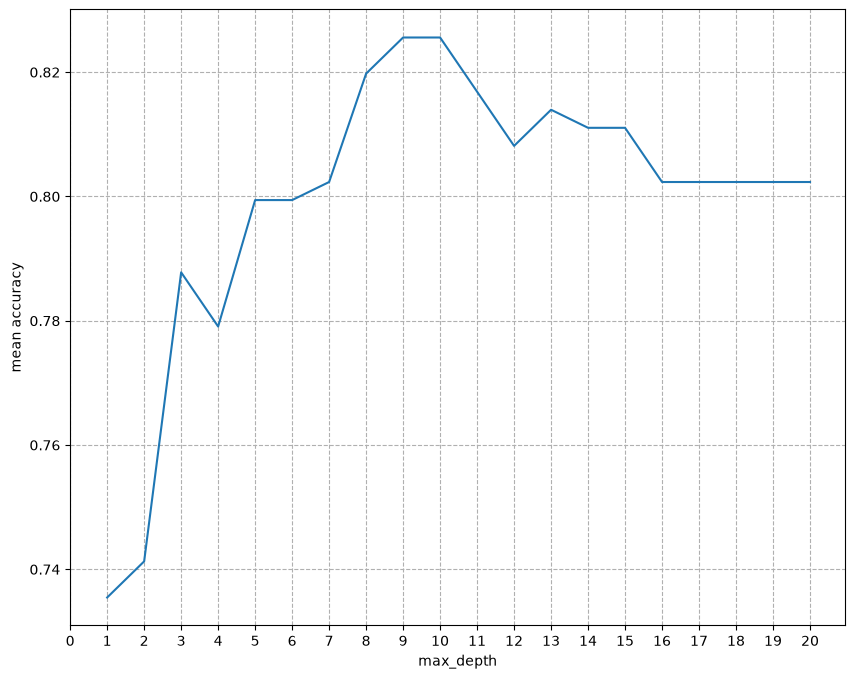

In [24]:
# Підбираємо параметр max_depth та будуємо графік точності
accur = []
max_kernels = 20
for k in range(1, max_kernels + 1):
    decision_tree = DecisionTreeClassifier(max_depth=k, random_state=1)
    decision_tree.fit(x_train, y_train)
    accur.append(decision_tree.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_kernels + 1), accur)
plt.xticks(range(0, max_kernels + 1, 1))
plt.xlabel('max_depth')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

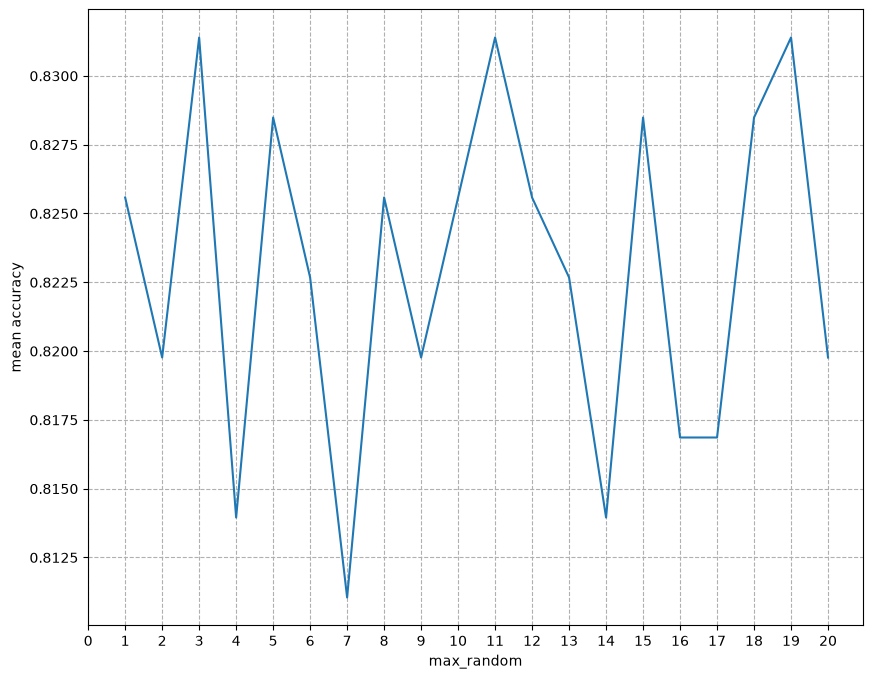

In [25]:
# Підбираємо параметр random_state та будуємо графік точності
accur = []
max_random = 20
for k in range(1, max_random + 1):
    decision_tree = DecisionTreeClassifier(max_depth=9, random_state=k)
    decision_tree.fit(x_train, y_train)
    accur.append(decision_tree.score(x_test, y_test))

plt.figure(figsize=(10, 8))
plt.plot(range(1, max_random + 1), accur)
plt.xticks(range(0, max_random + 1, 1))
plt.xlabel('max_random')
plt.ylabel('mean accuracy')
plt.grid(linestyle='--')
plt.show()

In [26]:
# Підставляємо визначені параметри та оцінюємо точність моделі
decision_tree = DecisionTreeClassifier(max_depth=9, random_state=8)
tree_scores = cross_val_score(decision_tree, x_train, y_train, cv=5)
print("Cross val mean:", tree_scores.mean())
decision_tree.fit(x_train, y_train)
print('Decision Tree mean accuracy = ', decision_tree.score(x_test, y_test))

Cross val mean: 0.8330537491705374
Decision Tree mean accuracy =  0.8255813953488372


# Порівняння результатів
Аналізуємо швидкість, точність (Accuracy) та F1-Score всіх розроблених моделей на навчальній та тестовій вибірках.

In [27]:
models = {
    'Gradient Boosting': gradboost,
    'Random Forest': randomforest,
    'Extra Trees': extratrees,
    'Decision Tree': decision_tree
}

print("Accuracy on training data")
for name, model in models.items():
    start = time.time()
    acc_train = model.score(x_train, y_train)
    duration = time.time() - start
    print(f"{name} : {acc_train:.4f} (Time: {duration:.4f} sec)")

print("\nAccuracy on test data")
for name, model in models.items():
    start = time.time()
    acc_test = model.score(x_test, y_test)
    duration = time.time() - start
    print(f"{name} : {acc_test:.4f} (Time: {duration:.4f} sec)")

print("\nF1 Score on training data")
for name, model in models.items():
    start = time.time()
    y_pred_train = model.predict(x_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    duration = time.time() - start
    print(f"{name} : {f1_train:.4f} (Time: {duration:.4f} sec)")

print("\nF1 Score on test data")
for name, model in models.items():
    start = time.time()
    y_pred_test = model.predict(x_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    duration = time.time() - start
    print(f"{name} : {f1_test:.4f} (Time: {duration:.4f} sec)")

Accuracy on training data
Gradient Boosting : 1.0000 (Time: 0.0101 sec)
Random Forest : 0.9169 (Time: 0.0087 sec)
Extra Trees : 0.9001 (Time: 0.0110 sec)
Decision Tree : 0.9643 (Time: 0.0010 sec)

Accuracy on test data
Gradient Boosting : 0.8721 (Time: 0.0041 sec)
Random Forest : 0.8430 (Time: 0.0047 sec)
Extra Trees : 0.8401 (Time: 0.0055 sec)
Decision Tree : 0.8256 (Time: 0.0007 sec)

F1 Score on training data
Gradient Boosting : 1.0000 (Time: 0.0095 sec)
Random Forest : 0.9171 (Time: 0.0078 sec)
Extra Trees : 0.8998 (Time: 0.0084 sec)
Decision Tree : 0.9643 (Time: 0.0011 sec)

F1 Score on test data
Gradient Boosting : 0.8739 (Time: 0.0036 sec)
Random Forest : 0.8444 (Time: 0.0049 sec)
Extra Trees : 0.8390 (Time: 0.0052 sec)
Decision Tree : 0.8308 (Time: 0.0010 sec)


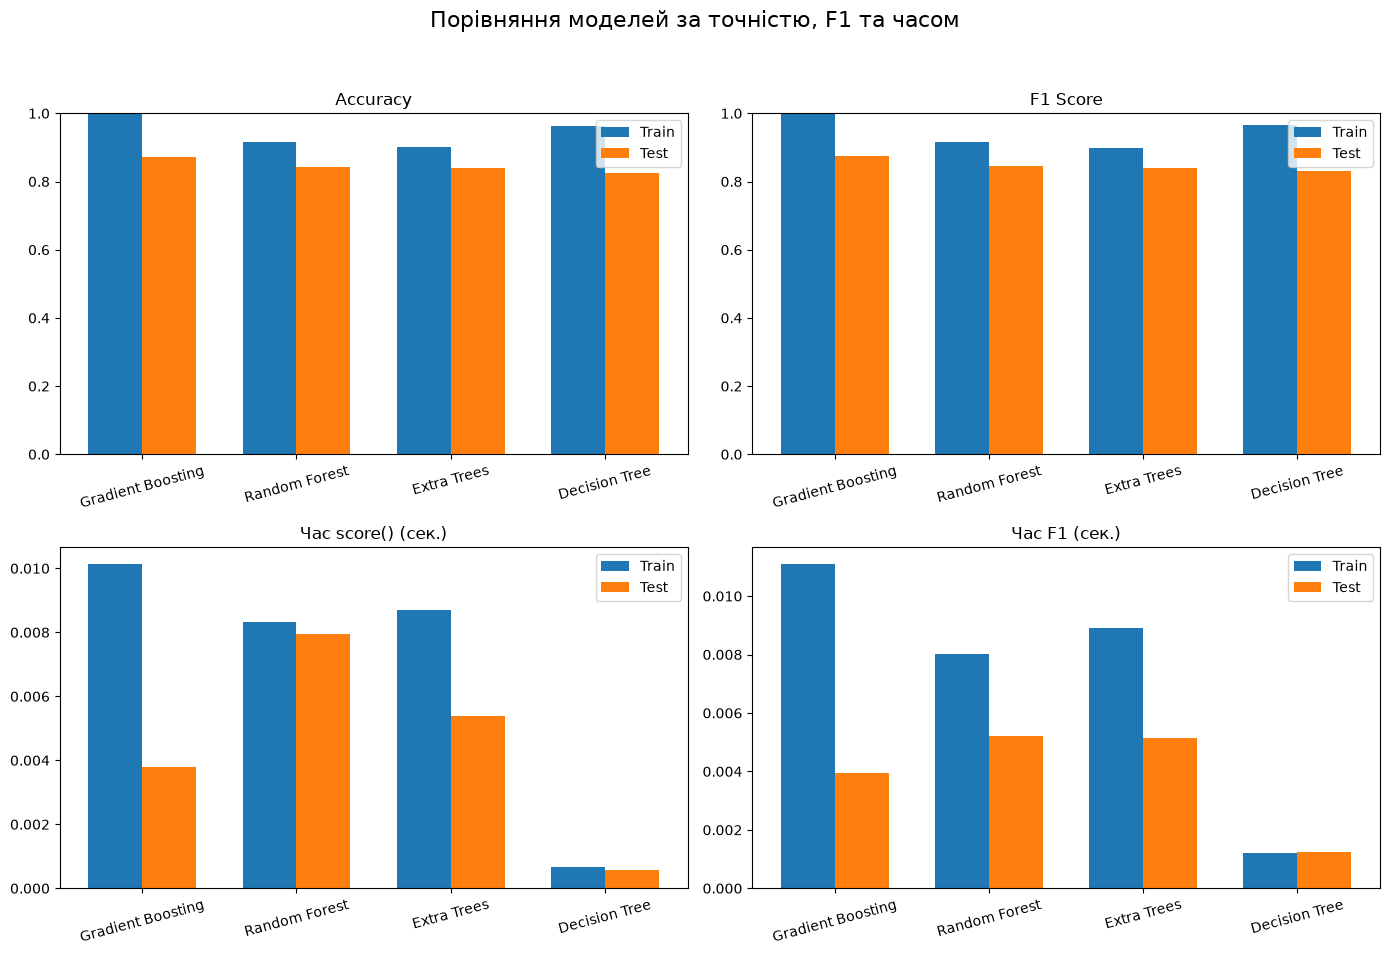

In [28]:
# Побудова графіків порівняння моделей
metrics = {
    'model': [],
    'accuracy_train': [],
    'accuracy_test': [],
    'f1_train': [],
    'f1_test': [],
    'time_accuracy_train': [],
    'time_accuracy_test': [],
    'time_f1_train': [],
    'time_f1_test': []
}

# Розрахунок метрик
for name, model in models.items():
    metrics['model'].append(name)
    
    start = time.time()
    acc_train = model.score(x_train, y_train)
    metrics['time_accuracy_train'].append(time.time() - start)
    metrics['accuracy_train'].append(acc_train)
    
    start = time.time()
    acc_test = model.score(x_test, y_test)
    metrics['time_accuracy_test'].append(time.time() - start)
    metrics['accuracy_test'].append(acc_test)
    
    start = time.time()
    y_pred_train = model.predict(x_train)
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    metrics['time_f1_train'].append(time.time() - start)
    metrics['f1_train'].append(f1_train)
    
    start = time.time()
    y_pred_test = model.predict(x_test)
    f1_test = f1_score(y_test, y_pred_test, average='weighted')
    metrics['time_f1_test'].append(time.time() - start)
    metrics['f1_test'].append(f1_test)

labels = metrics['model']
x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Порівняння моделей за точністю, F1 та часом", fontsize=16)

axs[0, 0].bar(x - width/2, metrics['accuracy_train'], width, label='Train')
axs[0, 0].bar(x + width/2, metrics['accuracy_test'], width, label='Test')
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_xticks(x)
axs[0, 0].set_xticklabels(labels, rotation=15)
axs[0, 0].set_ylim(0, 1)
axs[0, 0].legend()

axs[0, 1].bar(x - width/2, metrics['f1_train'], width, label='Train')
axs[0, 1].bar(x + width/2, metrics['f1_test'], width, label='Test')
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_xticks(x)
axs[0, 1].set_xticklabels(labels, rotation=15)
axs[0, 1].set_ylim(0, 1)
axs[0, 1].legend()

axs[1, 0].bar(x - width/2, metrics['time_accuracy_train'], width, label='Train')
axs[1, 0].bar(x + width/2, metrics['time_accuracy_test'], width, label='Test')
axs[1, 0].set_title('Час score() (сек.)')
axs[1, 0].set_xticks(x)
axs[1, 0].set_xticklabels(labels, rotation=15)
axs[1, 0].legend()

axs[1, 1].bar(x - width/2, metrics['time_f1_train'], width, label='Train')
axs[1, 1].bar(x + width/2, metrics['time_f1_test'], width, label='Test')
axs[1, 1].set_title('Час F1 (сек.)')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(labels, rotation=15)
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()